<a href="https://colab.research.google.com/github/jfaraudo/Monte_Carlo_Metropolis_Examples/blob/master/Ising/ising_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Simulations at  238  different temperatures.
Simulation  1  of 238  at reduced temperature T= 1.8557321656002341
Simulation  2  of 238  at reduced temperature T= 1.9088441958430526
Simulation  3  of 238  at reduced temperature T= 2.255844416526363
Simulation  4  of 238  at reduced temperature T= 2.323479080476019
Simulation  5  of 238  at reduced temperature T= 2.80138324233242
Simulation  6  of 238  at reduced temperature T= 2.5527698824108156
Simulation  7  of 238  at reduced temperature T= 2.2683632385325145
Simulation  8  of 238  at reduced temperature T= 1.7566698297672692
Simulation  9  of 238  at reduced temperature T= 1.8967889150291952
Simulation  10  of 238  at reduced temperature T= 1.5463588918744469
Simulation  11  of 238  at reduced temperature T= 2.468072604043739
Simulation  12  of 238  at reduced temperature T= 2.412402834422049
Simulation  13  of 238  at reduced temperature T= 2.3474661957221445
Simulation  14  of 238  at reduced temperature T= 1.939843973678

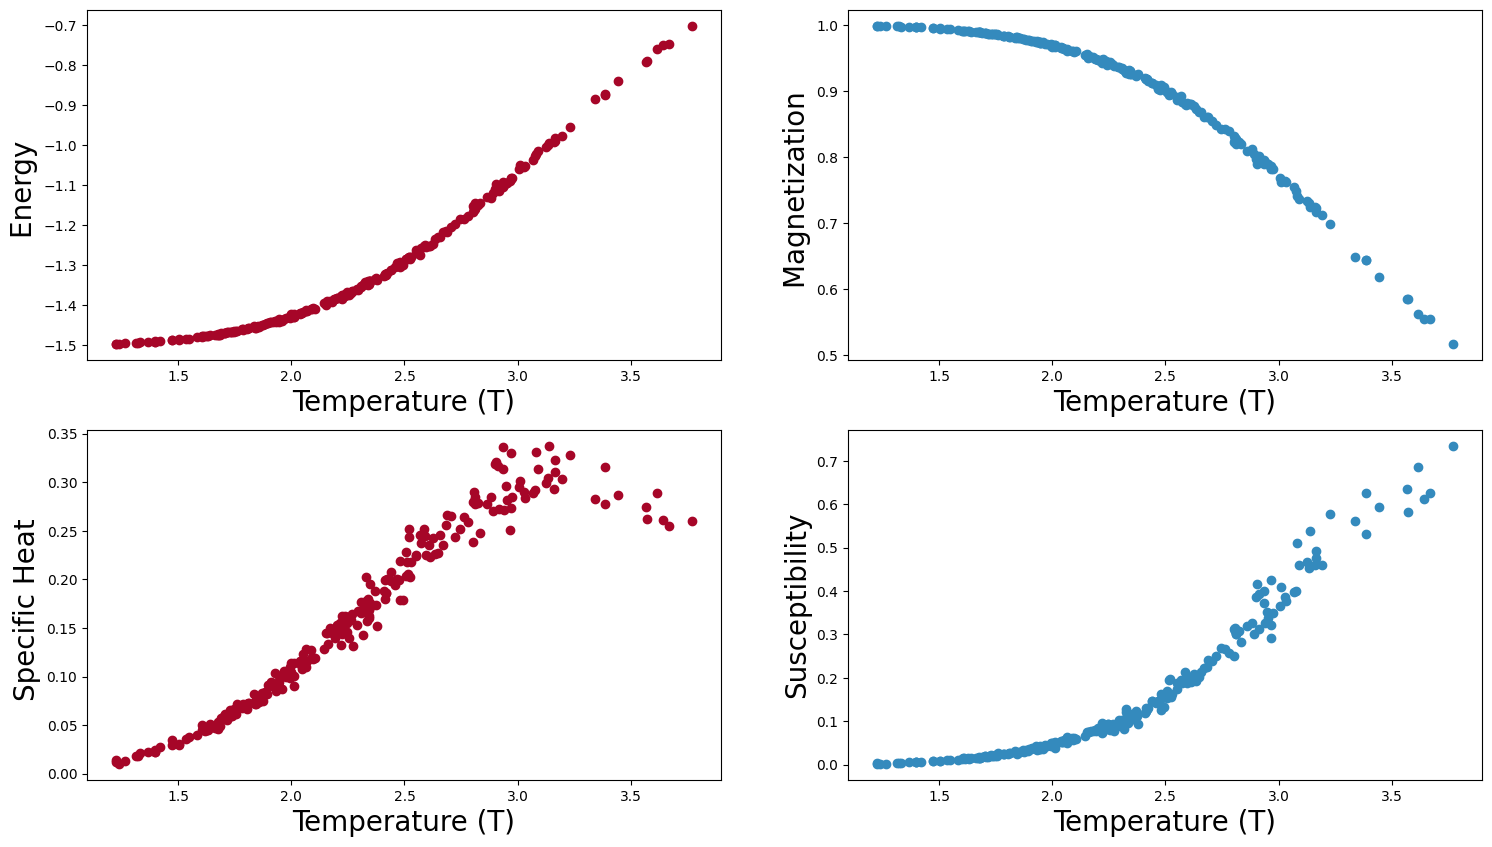

In [5]:
# -----------------------------------------------------------------
# INTRODUCTION TO MONTECARLO SIMULATION
# Simulation of 2D Ising model
# May 2018 - updated Feb 2023
# -----------------------------------------------------------------
#
# The algorithm is based on Dr Rajesh Singh (Cambridge University) blog with python resources in Physics.
# https://rajeshrinet.github.io/blog/2014/ising-model/
# Adapted by Jordi Faraudo 2018 for teaching purposes
# please look first to the ising_snapshots.py code
#
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt

#----------------------------------------------------------------------
##  BLOCK OF FUNCTIONS USED IN THE MAIN CODE
#----------------------------------------------------------------------

#Generation of a random initial state for NxN spins
def initialstate(N):
    ''' generates a random spin configuration for initial condition'''
    state = 2*np.random.randint(2, size=(N,N))-1
    return state

# Here we define the interactions of the model (2D spin Ising model)
# and the solution method (Metropolis Monte Carlo)
def mcmove(config, beta, h):
    '''Monte Carlo move using Metropolis algorithm '''
    for i in range(N):
        for j in range(N):
                #select random spin from NxN system
                a = np.random.randint(0, N)
                b = np.random.randint(0, N)
                s =  config[a, b]
                #calculate energy cost of this new configuration (the % is for calculation of periodic boundary condition)
                nb = config[(a+1)%N,b] + config[a,(b+1)%N] + config[(a-1)%N,b] + config[a,(b-1)%N]
                cost = 2*s*(nb + h)
                #flip spin or not depending on the cost and its Boltzmann factor
                ## (acceptance probability is given by Boltzmann factor with beta = 1/kBT
                if cost < 0:
                    s *= -1
                elif rand() < np.exp(-cost*beta):
                    s *= -1
                config[a, b] = s
    return config

#This function calculates the energy of a given configuration for the plots of Energy as a function of T
def calcEnergy(config, h):
    '''Energy of a given configuration'''
    energy = 0
    for i in range(len(config)):
        for j in range(len(config)):
            S = config[i,j]
            nb = config[(i+1)%N, j] + config[i,(j+1)%N] + config[(i-1)%N, j] + config[i,(j-1)%N]
            energy += -nb*S
    
    energy = energy / 4.0   # same normalization as original code
    field_term = -h * np.sum(config)

    return energy + field_term

#This function calculates the magnetization of a given
def calcMag(config):
    '''Magnetization of a given configuration'''
    mag = np.sum(config)
    return mag

#
# MAIN PROGRAM
#
# Initial parameters for calculation
## change the parameter below if you want to simulate a smaller system
nt      = 2**8        # number of temperature points
N       = 2**4        # size of the lattice, N x N
eqSteps = 2**10       # number of MC sweeps for equilibration
mcSteps = 2**10       # number of MC sweeps for calculation

h = 0.5 #external magnetic field

n1, n2  = 1.0/(mcSteps*N*N), 1.0/(mcSteps*mcSteps*N*N)
#Generate a random distribution of temperatures to make an exploration
tm = 2.269;    T=np.random.normal(tm, .64, nt)
T  = T[(T>1.2) & (T<3.8)];    nt = np.size(T)

Energy       = np.zeros(nt);   Magnetization  = np.zeros(nt)
SpecificHeat = np.zeros(nt);   Susceptibility = np.zeros(nt)


#----------------------------------------------------------------------
#  SIMULATION LOOP
#----------------------------------------------------------------------
print('Starting Simulations at ',len(T),' different temperatures.')
for m in range(len(T)):
    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)
    iT=1.0/T[m]
    iT2=iT*iT
    print('Simulation ',m+1,' of',len(T),' at reduced temperature T=',T[m])

    for i in range(eqSteps):         # equilibrate
        mcmove(config, iT, h)           # Monte Carlo moves

    for i in range(mcSteps):
        mcmove(config, iT, h)
        Ene = calcEnergy(config, h)     # calculate the energy
        Mag = calcMag(config)        # calculate the magnetisation

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag*Mag
        E2 = E2 + Ene*Ene

        Energy[m]         = n1*E1
        Magnetization[m]  = n1*M1
        SpecificHeat[m]   = (n1*E2 - n2*E1*E1)*iT2
        Susceptibility[m] = (n1*M2 - n2*M1*M1)*iT

#
# Plot everything
#

f = plt.figure(figsize=(18, 10)); # plot the calculated values

sp =  f.add_subplot(2, 2, 1 );
plt.plot(T, Energy, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Energy ", fontsize=20);

sp =  f.add_subplot(2, 2, 2 );
plt.plot(T, abs(Magnetization), 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Magnetization ", fontsize=20);

sp =  f.add_subplot(2, 2, 3 );
plt.plot(T, SpecificHeat, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Specific Heat ", fontsize=20);

sp =  f.add_subplot(2, 2, 4 );
plt.plot(T, Susceptibility, 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Susceptibility", fontsize=20);
plt.show()

Using 7 processes


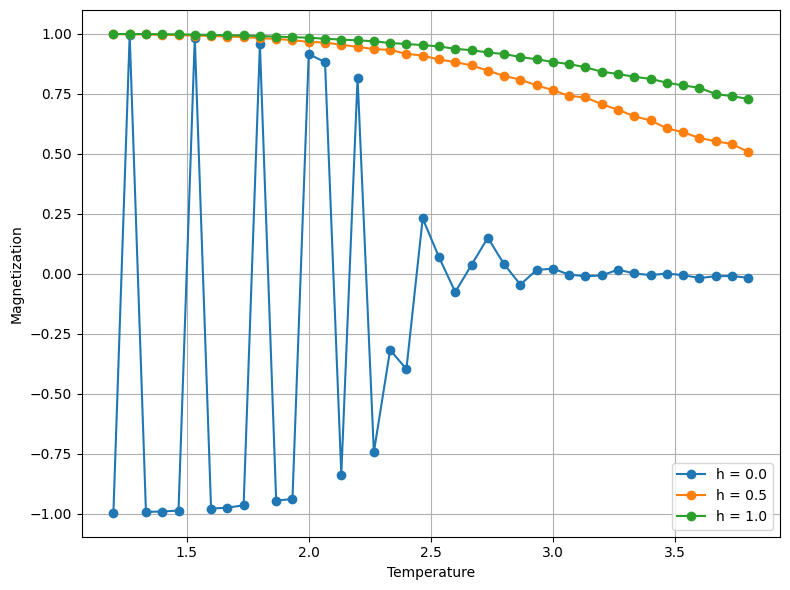

In [ ]:
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count

def initialstate(N):
    return 2 * np.random.randint(2, size=(N, N)) - 1

def mcmove(config, beta, h, N):
    for i in range(N):
        for j in range(N):
            a = np.random.randint(0, N)
            b = np.random.randint(0, N)
            s = config[a, b]

            nb = (
                config[(a + 1) % N, b]
                + config[a, (b + 1) % N]
                + config[(a - 1) % N, b]
                + config[a, (b - 1) % N]
            )

            cost = 2 * s * (nb + h)

            if cost < 0:
                s *= -1
            elif rand() < np.exp(-cost * beta):
                s *= -1

            config[a, b] = s

    return config

def calcEnergy(config, h, N):
    energy = 0
    for i in range(N):
        for j in range(N):
            S = config[i, j]
            nb = (
                config[(i + 1) % N, j]
                + config[i, (j + 1) % N]
                + config[(i - 1) % N, j]
                + config[i, (j - 1) % N]
            )
            energy += -nb * S

    energy = energy / 4.0
    field_term = -h * np.sum(config)
    return energy + field_term

def calcMag(config):
    return np.sum(config)

def simulate_temperature(args):
    T_val, h, N, eqSteps, mcSteps = args

    np.random.seed()  

    n1 = 1.0 / (mcSteps * N * N)
    n2 = 1.0 / (mcSteps * mcSteps * N * N)

    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)

    iT = 1.0 / T_val
    iT2 = iT * iT

    for _ in range(eqSteps):
        mcmove(config, iT, h, N)

    for _ in range(mcSteps):
        mcmove(config, iT, h, N)

        Ene = calcEnergy(config, h, N)
        Mag = calcMag(config)

        E1 += Ene
        M1 += Mag
        E2 += Ene * Ene
        M2 += Mag * Mag

    Energy = n1 * E1
    Magnetization = n1 * M1
    SpecificHeat = (n1 * E2 - n2 * E1 * E1) * iT2
    Susceptibility = (n1 * M2 - n2 * M1 * M1) * iT

    return Energy, Magnetization, SpecificHeat, Susceptibility


if __name__ == "__main__":
    N = 2**4
    eqSteps = 2**10
    mcSteps = 2**10

    T = np.linspace(1.2, 3.8, 40)
    fields = [0.0, 0.5, 1.0]

    Energy_all = {}
    Mag_all = {}
    Cv_all = {}
    Chi_all = {}

    nproc = max(1, cpu_count() - 1)
    print(f"Using {nproc} processes")

    for h in fields:
        args_list = [(T_val, h, N, eqSteps, mcSteps) for T_val in T]

        with Pool(processes=nproc) as pool:
            results = pool.map(simulate_temperature, args_list)

        results = np.array(results)

        Energy_all[h] = results[:, 0]
        Mag_all[h] = results[:, 1]
        Cv_all[h] = results[:, 2]
        Chi_all[h] = results[:, 3]

    #plot
    plt.figure(figsize=(8, 6))
    for h in fields:
        plt.plot(T, Mag_all[h], marker='o', label=f"h = {h}")
    plt.xlabel("Temperature")
    plt.ylabel("Magnetization")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

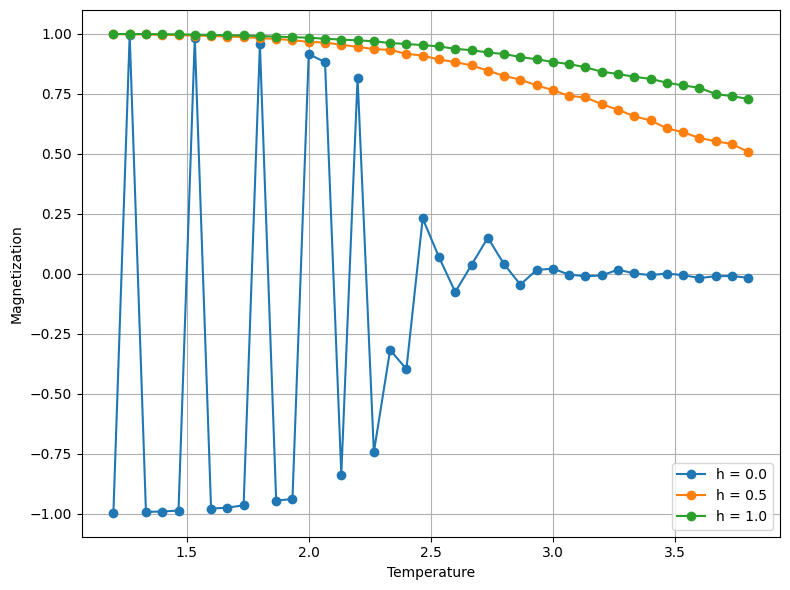

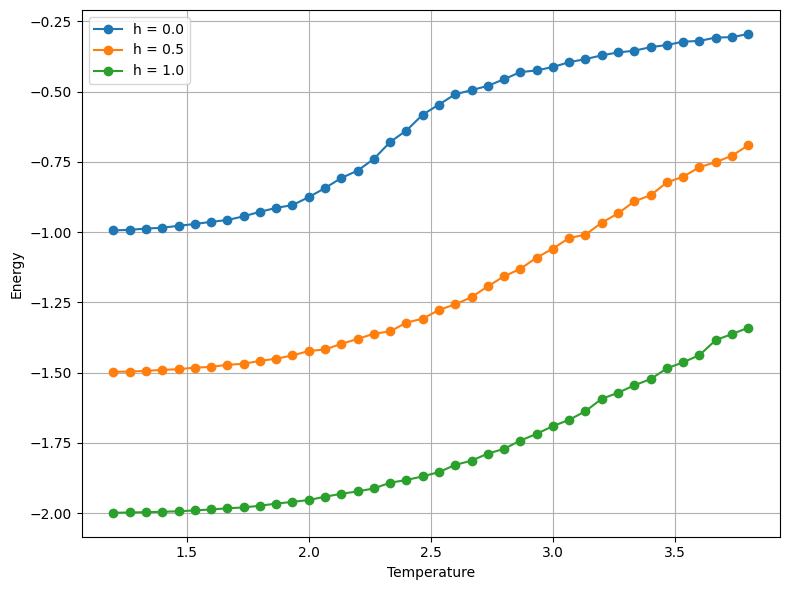

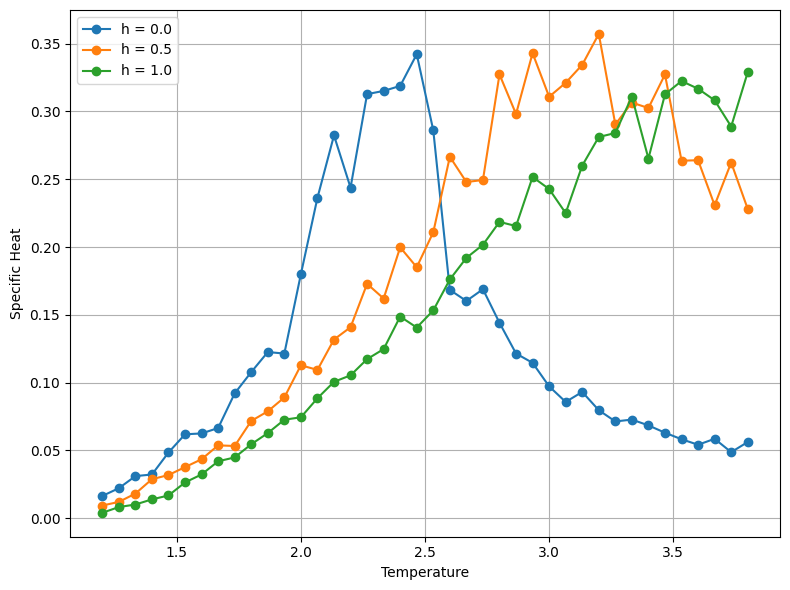

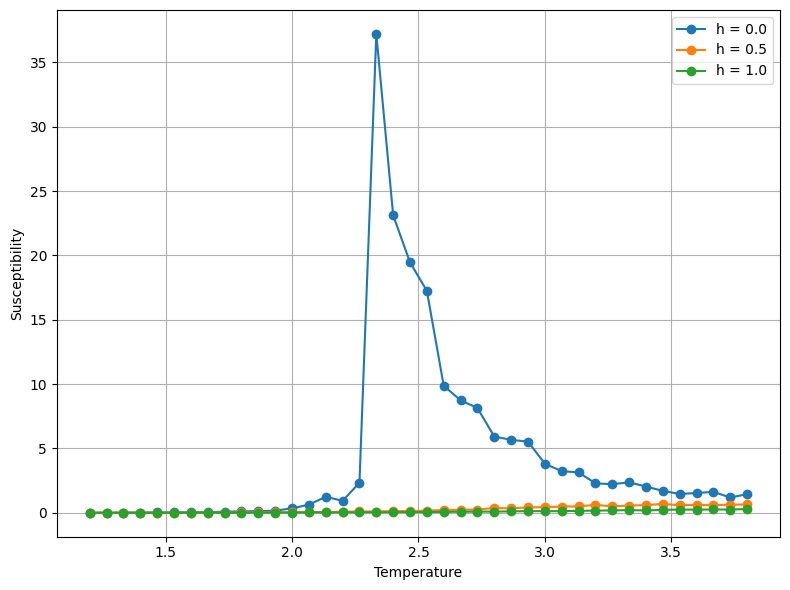

In [10]:
#magnetització vs T

plt.figure(figsize=(8,6))

for h in fields:
    plt.plot(T, Mag_all[h], marker='o', label=f"h = {h}")

plt.xlabel("Temperature")
plt.ylabel("Magnetization")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("magnetization_vs_T.png", dpi=300)
plt.show()

#Energia vs T

plt.figure(figsize=(8,6))

for h in fields:
    plt.plot(T, Energy_all[h], marker='o', label=f"h = {h}")

plt.xlabel("Temperature")
plt.ylabel("Energy")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("energy_vs_T.png", dpi=300)
plt.show()

#Calor específic

plt.figure(figsize=(8,6))

for h in fields:
    plt.plot(T, Cv_all[h], marker='o', label=f"h = {h}")

plt.xlabel("Temperature")
plt.ylabel("Specific Heat")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("specificheat_vs_T.png", dpi=300)
plt.show()

#susceptibilitat

plt.figure(figsize=(8,6))

for h in fields:
    plt.plot(T, Chi_all[h], marker='o', label=f"h = {h}")

plt.xlabel("Temperature")
plt.ylabel("Susceptibility")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("susceptibility_vs_T.png", dpi=300)
plt.show()